# Pythia norm-fraction distributions

Inspect the true syntax norm-fraction distributions saved in `norms.npz` for each checkpoint and layer.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

models = [
    'pythia6p9b_step0',
    'pythia6p9b_step256',
    'pythia6p9b_step512',
    'pythia6p9b_step2000',
    'pythia6p9b_step4000',
    'pythia6p9b_step16000',
    'pythia6p9b_step64000',
    'pythia6p9b_step143000',
]
min_token_length = 3
n_samples = 2018
global_center_flag = 1
avg_tokens = 0
n_tokens = None

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 15
plt.rcParams['figure.autolayout'] = True


def norms_path(model):
    root = (
        Path('/home/acevedo/syn-sem/pythia/results')
        / f'model_{model}'
        / f'avg_tokens_{avg_tokens}'
        / f'min_token_length_{min_token_length}'
        / f'n_samples_{n_samples}'
    )
    if avg_tokens == 0 and n_tokens is not None and n_tokens != min_token_length:
        root = root / f'n_tokens_{n_tokens}'
    return root / 'norms' / f'global_center_flag_{global_center_flag}' / 'norms.npz'


runs = {}
for model in models:
    path = norms_path(model)
    if not path.exists():
        print(f'missing: {path}')
        continue
    runs[model] = np.load(path)

available_models = list(runs)
available_models


missing: /home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step256/avg_tokens_0/min_token_length_3/n_samples_2018/norms/global_center_flag_1/norms.npz
missing: /home/acevedo/syn-sem/pythia/results/model_pythia6p9b_step2000/avg_tokens_0/min_token_length_3/n_samples_2018/norms/global_center_flag_1/norms.npz


['pythia6p9b_step0',
 'pythia6p9b_step512',
 'pythia6p9b_step4000',
 'pythia6p9b_step16000',
 'pythia6p9b_step64000',
 'pythia6p9b_step143000']

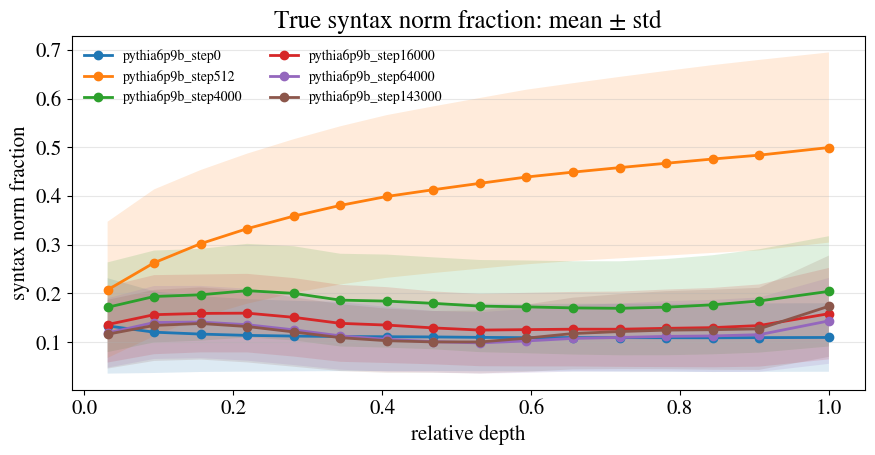

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(9.0, 4.8))

for model in available_models:
    data = runs[model]
    rel_depths = data['rel_depths']
    syn_means = data['syn_means']
    syn_stds = data['syn_stds']
    ax.plot(rel_depths, syn_means, marker='o', linewidth=2.0, label=model)
    ax.fill_between(rel_depths, syn_means - syn_stds, syn_means + syn_stds, alpha=0.15)

ax.set_xlabel('relative depth')
ax.set_ylabel('syntax norm fraction')
ax.set_title('True syntax norm fraction: mean ± std')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=10, ncol=2)
plt.show()


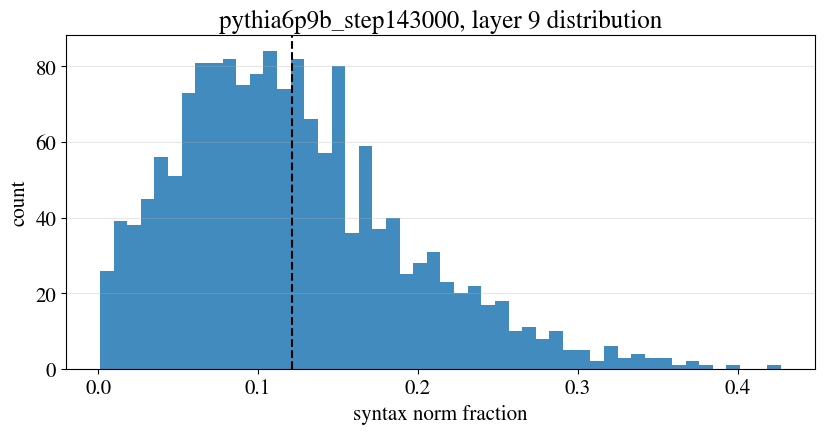

In [4]:
checkpoint_for_distribution = available_models[-1]
layer_index = 4

data = runs[checkpoint_for_distribution]
syn_dists = data['syn_dists']
layer_vals = data['layer_vals']

fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.6))
ax.hist(syn_dists[layer_index], bins=50, color='#1f77b4', alpha=0.85)
ax.axvline(data['syn_means'][layer_index], color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('syntax norm fraction')
ax.set_ylabel('count')
ax.set_title(f'{checkpoint_for_distribution}, layer {layer_vals[layer_index]} distribution')
ax.grid(axis='y', alpha=0.3)
plt.show()
